In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import math
from matplotlib.scale import FuncScale



from pathlib import Path

from os.path import join
import os
from functools import partial
import pathlib
import shutil

import re


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.colors as mcolors

from scipy.stats import bootstrap

In [40]:
model_comparisons = [
    "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_2025",
    "/glade/derecho/scratch/dkimpara/goes_10km_train/DOP/10m_big_dop/forecasts_2025",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/DOP/10m_big_train_anneal/forecasts_2025",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/30m_omid/forecasts_2025",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2025",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts_2022",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_inv/forecasts_2022",
]

model_comparisons = {
    Path(d).parent.name: d for d in model_comparisons
}


comparisons = model_comparisons

colors = {
    "10m_persistence": "0.5",
    "10m_climo": "0",
    "10m_big": "#D81B60", #magenta ish
    "10m_big_dop": "#FFC107",
    "10m_big_train_anneal": "c",
    "20m_big": "#004D40", #greenish
    "20m_big3": "lime",
    "20m_inv": "y",
    "30m_omid": "#1E88E5", #bluish
    "30m_mpas": "#1E88E5", #bluish
}
linestyles = {
    "10m_persistence": "--",
    # "10m_climo": "--",
} 

dfs = {k: pd.read_parquet(join(path, "verif.parquet")) for k, path in comparisons.items()}
dfs_all = {k: {p.name: pd.read_parquet(p)
               for p in sorted(Path(v).iterdir())
               if (p.name != "verif.parquet") and "parquet" in p.name}
           for k,v in comparisons.items()}

In [42]:
baseline_model = "10m_big_dop"
compare_model = "10m_big"

metric = "MAESS_region_right_C13"

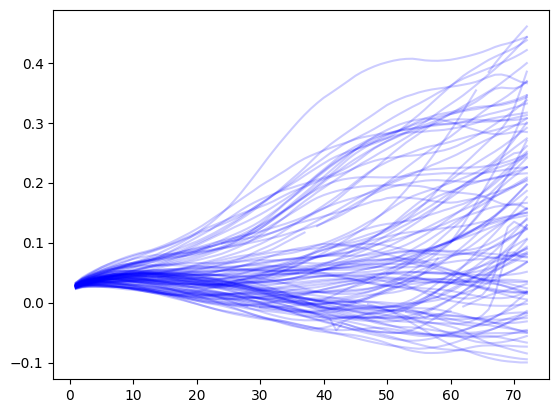

In [43]:
diffs = []
for verif_filename, df_baseline in dfs_all[baseline_model].items():
    df_model = dfs_all[compare_model][verif_filename]

    diff = df_model[metric] - df_baseline[metric]
    plt.plot(df_baseline["forecast_step"], diff,
             c = "b", alpha=0.2)
    diffs.append(diff)

In [10]:
diffs_cube = np.stack(diffs)


In [88]:
results = []

for step in range(len(diffs[0])):
    diff_test = [diff[step] for diff in diffs]
    clean = [a for a in diff_test if not np.isnan(a).any()]
    
    # bootstrap
    res = bootstrap((clean, ), np.mean,
          n_resamples=50000, batch=None, vectorized=None, paired=False,
          # axis=0,
          confidence_level=0.999,
          alternative='two-sided',
          method='BCa',
               )

    results.append(res)

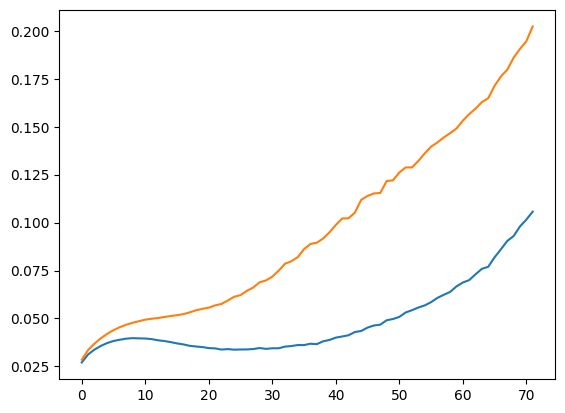

In [89]:
low_ints = [res.confidence_interval.low for res in results]
high_ints = [res.confidence_interval.high for res in results]
plt.plot(range(len(low_ints)), low_ints)
plt.plot(range(len(low_ints)), high_ints)